#### 00_demo.ipynb

- Start here to check what you can do with this small experimental package

In [4]:

using Pkg
Pkg.add("Printf")
Pkg.activate("..") # From demos/ we go one level up to the project root
Pkg.instantiate()  # Optional, but recommended to ensure all dependencies are installed
using Printf
using MiniOps
using Random
using LinearAlgebra
using Plots
using Random 
using SeisProcessing


    Updating registry at `~/.julia/registries/General.toml`
      Compat entries added for Printf
    Updating `~/Dropbox/MiniOps/Project.toml`
  [de0858da] + Printf v1.11.0
    Manifest No packages added to or removed from `~/Dropbox/MiniOps/Manifest.toml`
  Activating project at `~/Dropbox/MiniOps`
Precompiling packages...
    736.8 ms  ✓ MiniOps
  1 dependency successfully precompiled in 1 seconds. 383 already precompiled.
  29 dependencies precompiled but different versions are currently loaded (ArgTools, Base64, Dates, Downloads, InteractiveUtils, JuliaSyntaxHighlighting, LibCURL, LibCURL_jll, LibGit2, LibGit2_jll, LibSSH2_jll, Logging, Markdown, Mmap, MozillaCACerts_jll, NetworkOptions, OpenSSL_jll, Pkg, Pkg → REPLExt, Printf, REPL, StyledStrings, TOML, Tar, UUIDs, Unicode, Zlib_jll, nghttp2_jll and p7zip_jll). Restart julia to access the new versions. Otherwise, 253 dependents of these packages may trigger further precompilation to work with the unexpected versions.


In [ ]:
# Pad operator (use for FFT-based interp)

n1, n2 = 3,3
p1, p2 = 2, 2
P = pad_op((n1,n2),(p1,p2), (p1,p2))
A = randn(n1,n2)
P*A

In [ ]:
# Multichannel Convolution

Random.seed!(0)

# Y = A * X Multichannel convolution
# X'= A'* Y Multichannel one-side croscorrlation

h  = [1.0, 2.0, -1.0] # Wavelet 

A  = conv1d_cols_op(h)

nt, ntr = 50, 100
X  = randn(nt, ntr)                     # test input

Y  = A * X

Z  = randn(size(Y))                     # test output

ok, err = adjoint_test(A, X, Z)         # <AX,Z> = <A'Z,X>
@show ok err;


In [ ]:
# Composition of operators

h = randn(14)
B = conv1d_op(h)       # B*x is 1D convolution of x with h

result = linearity_test(B, randn(10), randn(10); ntests=3, tol=1e-10)
println(B.name, " Linearity test : " , result)

result = adjoint_test(B, randn(10), randn(10+14-1); tol=1e-10)
println(B.name, " Adjoint test   : ", result)

e = opnorm_power(B, randn(10); niter=20)
println(B.name, " Maximum Eig    : ", e)

Sc = scaling_op(3.0)
result = is_selfadjoint(Sc, randn(20); tol=1e-10)
println(Sc.name, " Self adjoint ? ", result)

Sc = scaling_op(0.3)
T=Sc*Sc
T.name


In [ ]:
# 1D FFT Operator 

B = fft_op() # Size agnostic (fft_unplanned)

result = linearity_test(B, randn(128), randn(128); ntests=3, tol=1e-10)
println(B.name, " Linearity test : " , result)

result = adjoint_test(B, randn(128), randn(128); tol=1e-10)
println(B.name, " Adjoint test   : ", result)

e = opnorm_power(B, randn(ComplexF64,128); niter=10)
println(B.name, " Maximum Eig    : ", e)
println(" Size n of B: ", B.n)
println(" Size m of B: ", B.m)

In [ ]:
# 1D FFT Operator (Repeat with operator that knows size (fft_planned))

B = fft_op(randn(128)) 

result = linearity_test(B, randn(128), randn(128); ntests=3, tol=1e-10)
println(B.name, " Linearity test : " , result)

result = adjoint_test(B, randn(128), randn(128); tol=1e-10)
println(B.name, " Adjoint test   : ", result)

e = opnorm_power(B, randn(ComplexF64,128); niter=10)
println(B.name, " Maximum Eig    : ", e)
println(" Size n of B: ", B.n)
println(" Size m of B: ", B.m)

In [ ]:
# 4D FFT Operator (Repeat with operator that knows size (fft_planned))

B = fft_op(randn(64,64,64,64)) 

result = linearity_test(B, randn(64,64,64,64), randn(64,64,64,64); ntests=3, tol=1e-10)
println(B.name, " Linearity test : " , result)

result = adjoint_test(B, randn(64,64,64,64), randn(64,64,64,64); tol=1e-10)
println(B.name, " Adjoint test   : ", result)

e = opnorm_power(B, randn(ComplexF64,64,64,64,64); niter=10)
println(B.name, " Maximum Eig    : ", e)
println(" Size n of B: ", B.n)
println(" Size m of B: ", B.m)


CGLS
    iter     rel_residual         residual             cost
------------------------------------------------------------
       0     1.000000e+00     3.438087e+00     5.910222e+00
      20     7.749462e-02     2.664333e-01     2.078761e-01
      36     7.734078e-02     2.659043e-01     2.078440e-01

ISTA
    iter     rel_residual         residual             cost
------------------------------------------------------------
       0     1.000000e+00     3.438087e+00     5.910222e+00
      20     1.556926e-01     5.352846e-01     1.008982e+00
      40     1.296197e-01     4.456439e-01     9.318993e-01
      60     1.157875e-01     3.980875e-01     9.062677e-01
      80     1.138508e-01     3.914291e-01     9.022388e-01
     100     1.133710e-01     3.897795e-01     8.990520e-01
     120     1.128607e-01     3.880248e-01     8.960307e-01
     140     1.122821e-01     3.860355e-01     8.930997e-01
     160     1.116525e-01     3.838711e-01     8.902530e-01
     180     1.109282e-01 

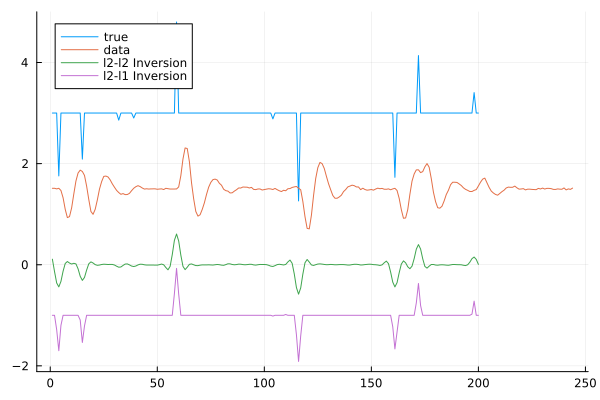

In [10]:
# Seismic Deconvolution Example

# seismicwavelet
  w = seismic_wavelet(f0=34.0,dt=0.002)

# Reflectivity
  M = 200; N = 10; x = zeros(M); x[randperm(M)[1:N]] = randn(N) 

# The wavelet convolution operator 
  C = conv1d_op(w) 

# Make data and add noise 
  y = C*x; y = y + 0.01*randn(size(y))

# Inversion with Damped Least-squares 
  μ = 0.1
  x1  = cgls(C, y, μ, zeros(200); tol=1e-4, max_iter=240,verbose=true)

# Inversion via ISTA (L2-L1) 
  e = opnorm_power(C,randn(200)) # Max eigen of C'C 
  ν = 0.98/e^2.  # Step size 
  x2 = ista(C, y, zeros(200), μ, ν; niter=200, verbose=true);

# Plots
  plot(x.+3,label="true")
  plot!(y.+1.5,label="data")
  plot!(x1, label="l2-l2 Inversion")
  plot!(x2.-1, label="l2-l1 Inversion")

